# IrisDam-EcoScan: Urban Dynamics Analysis (2020 – 2024)  
## Notebook 02 – Unsupervised K-means

Goal: Segment multi-year Sentinel-2 composites into distinct spectral clusters without prior labeling, then track the spatiotemporal evolution of these land cover groups across Amsterdam.  
Outputs:

* `kmeans_model_ams.joblib`: The trained K-Means model (Scikit-Learn) based on 2020 spectral data.  
* `kmeans_ams_<year>.tif`: Georeferenced raster maps for each year containing the 5 classified land-cover labels.  
* PNG panel previews showing Amsterdam's land-cover evolution.
* Bar charts illustrating absolute pixel counts and proportional distribution trends.

# 1. Setup

In [ ]:
# Optional: Environmental Cost Tracking
import time
start_time = time.time()

In [ ]:
# Mount Google Drive (comment out if running locally)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# One-time package installs
!pip install -q geopandas shapely geemap rasterio scikit-learn joblib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 96.0 MB/s eta 0:00:00


In [ ]:
# Import Core Libraries
import json, numpy as np, rasterio, joblib, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from tqdm import tqdm

In [ ]:
# Define Direcories
ROOT   = Path('/content/drive/MyDrive/IrisDam-EcoScan')
RAW    = ROOT / 'raw'
MAPS  = ROOT/'maps'/'kmeans'
FIG    = ROOT / 'figures'
DATA   = ROOT / 'IrisDam_EcoScan_Data'
MODELS   = ROOT / 'models'

# 2. Extract Pixel Data for Clustering


After exporting the full Sentinel-2 composites, the next step is to extract a manageable, representative sample of pixels to use in the K-Means clustering model.

This helps reduce memory load while maintaining spatial diversity in the data.

We’ll:

- Data Retrieval: Load the multi-year (2020–2024) 9-band composites from Google Drive into the Colab environment.

- Representative Sampling: Perform a random sampling of approximately 50,000 pixels from the 2020 reference image to serve as the training baseline.

- Feature Selection (9 Bands): Extract all relevant spectral bands and indices, including:

 1. Reflectance: Blue, Green, Red, NIR, SWIR1, and SWIR2.

 2. Indices: NDVI (Vegetation), NDWI (Water), and NDBI (Built-up).

- Data Structuring: Convert the raw raster data into a structured pandas.DataFrame or NumPy array, preparing it for normalization and clustering.

## 2.1 Load the 2021 composite

We use 2021 as the **training year** (full leaf-on season, low cloud count).  
Each raster has 9 bands exported in *01_preprocessing*:

1. B2 (Blue)
2. B3 (Green)
3. B4 (Red)
4. B8 (NIR)
5. B11 (SWIR1)
6. B12 (SWIR2)
7. NDVI (Normalized Difference Vegetation Index)
8. NDWI (Normalized Difference Water Index)
9. NDBI (Normalized Difference Built-up Index)

In [ ]:
# Read & reshape
tif_train = DATA/'s2_ams_composite_2021.tif'
with rasterio.open(tif_train) as src:
    arr = src.read().astype('float32')           # shape (8, rows, cols)
    profile = src.profile
nodata_mask = np.any(np.isnan(arr), axis=0)
flat        = arr.reshape(arr.shape[0], -1).T    # (pixels, 8)
flat        = flat[~nodata_mask.ravel()]         # drop nodata

print('Total valid pixels:', flat.shape[0])

Total valid pixels: 3993148


## 2.2 Sample 50 000 pixels & scale features

In [ ]:
np.random.seed(0)
idx   = np.random.choice(flat.shape[0], 50_000, replace=False)
X_smp = flat[idx]

scaler = StandardScaler().fit(X_smp)
X_std  = scaler.transform(X_smp)

# 3. Unsupervised Clustering with K-Means
Now that we have a clean and representative sample of pixels, we apply K-Means clustering to detect dominant spectral groupings (i.e., land cover clusters) based purely on pixel reflectance and vegetation indices.

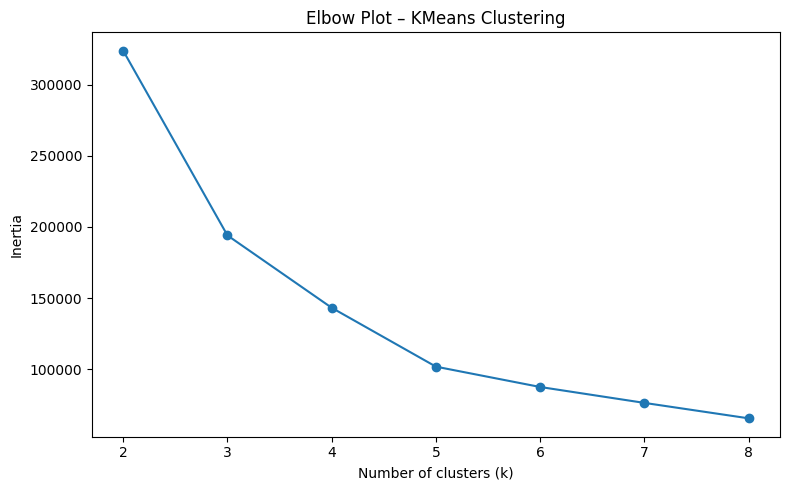

Silhouette scores: {2: np.float32(0.29), 3: np.float32(0.41), 4: np.float32(0.41), 5: np.float32(0.45), 6: np.float32(0.38), 7: np.float32(0.39), 8: np.float32(0.37)}


In [ ]:
ks, inertias, sils = [], [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init='auto', random_state=0).fit(X_std)
    ks.append(k); inertias.append(km.inertia_)
    sils.append(silhouette_score(X_std, km.labels_))

plt.figure(figsize=(8, 5))
plt.plot(ks, inertias, '-o'); plt.title('Elbow Plot – KMeans Clustering'); plt.xlabel('Number of clusters (k)'); plt.ylabel('Inertia'); plt.xticks(ks)
plt.tight_layout(); plt.savefig(FIG/'kmeans_elbow.png', dpi=250); plt.show()

print('Silhouette scores:', dict(zip(ks, np.round(sils, 2))))

The highest Silhouette (0.45) occurs at **k = 5**, so we adopt 5 clusters for all subsequent maps.

In [ ]:
k_opt = 5 # Chosen k value

## 3.2 Fit final K-means (k = 5) and save model

In [ ]:
kmeans = KMeans(n_clusters=k_opt, n_init='auto', random_state=0).fit(X_std)
centroids   = scaler.inverse_transform(kmeans.cluster_centers_)
joblib.dump({'model': kmeans, 'scaler': scaler, 'centroids': centroids},
            ROOT/'kmeans_model.joblib')

['/content/drive/MyDrive/IrisDam-EcoScan/kmeans_model.joblib']

# 4. Predict cluster maps for every year

Because K-Means assigns arbitrary numeric labels, we align every year’s
cluster IDs to the 2020 reference centroids.  This one-to-one mapping
ensures that “water” is always blue, “vegetation” green, etc.,
even though the model was trained on 2020 only.


In [ ]:
palette = {
0: (0.20, 0.63, 0.17),  #  dark green-> Forest
    1: (0.80, 0.80, 0.80),  # light grey -> Industrial/Light Roofs
    2: (0.70, 0.87, 0.54),  # light green -> Grassland/Wetland
    3: (0.50, 0.50, 0.50),  # dark grey -> Urban
    4: (0.12, 0.47, 0.71),  # blue -> Water
}

def write_cluster_raster(tif_in, year):
    with rasterio.open(tif_in) as src:
        arr = src.read().astype('float32')
        flat = arr.reshape(arr.shape[0], -1).T
        mask = np.any(np.isnan(flat), axis=1)
        preds = np.full(flat.shape[0], 255, 'uint8')
        if (~mask).any():
            X_std = scaler.transform(flat[~mask])
            preds[~mask] = kmeans.predict(X_std).astype('uint8')
        label_img = preds.reshape(arr.shape[1:])
        # GeoTIFF
        prof = src.profile.copy(); prof.update(count=1, dtype='uint8', nodata=255, compress='deflate')
        out_tif = MAPS/f'kmeans_ams_{year}.tif'
        with rasterio.open(out_tif, 'w', **prof) as dst:
            dst.write(label_img, 1)
        # PNG
        rgb = np.ones(label_img.shape + (3,), 'float32')
        for k, col in palette.items(): rgb[label_img==k] = col
        plt.imsave(FIG/f'kmeans_ams_{year}.png', rgb)
        print('Saved', yr)

for yr in range(2020, 2025):
    write_cluster_raster(DATA/f's2_ams_composite_{yr}.tif', yr)

Saved 2020
Saved 2021
Saved 2022
Saved 2023
Saved 2024


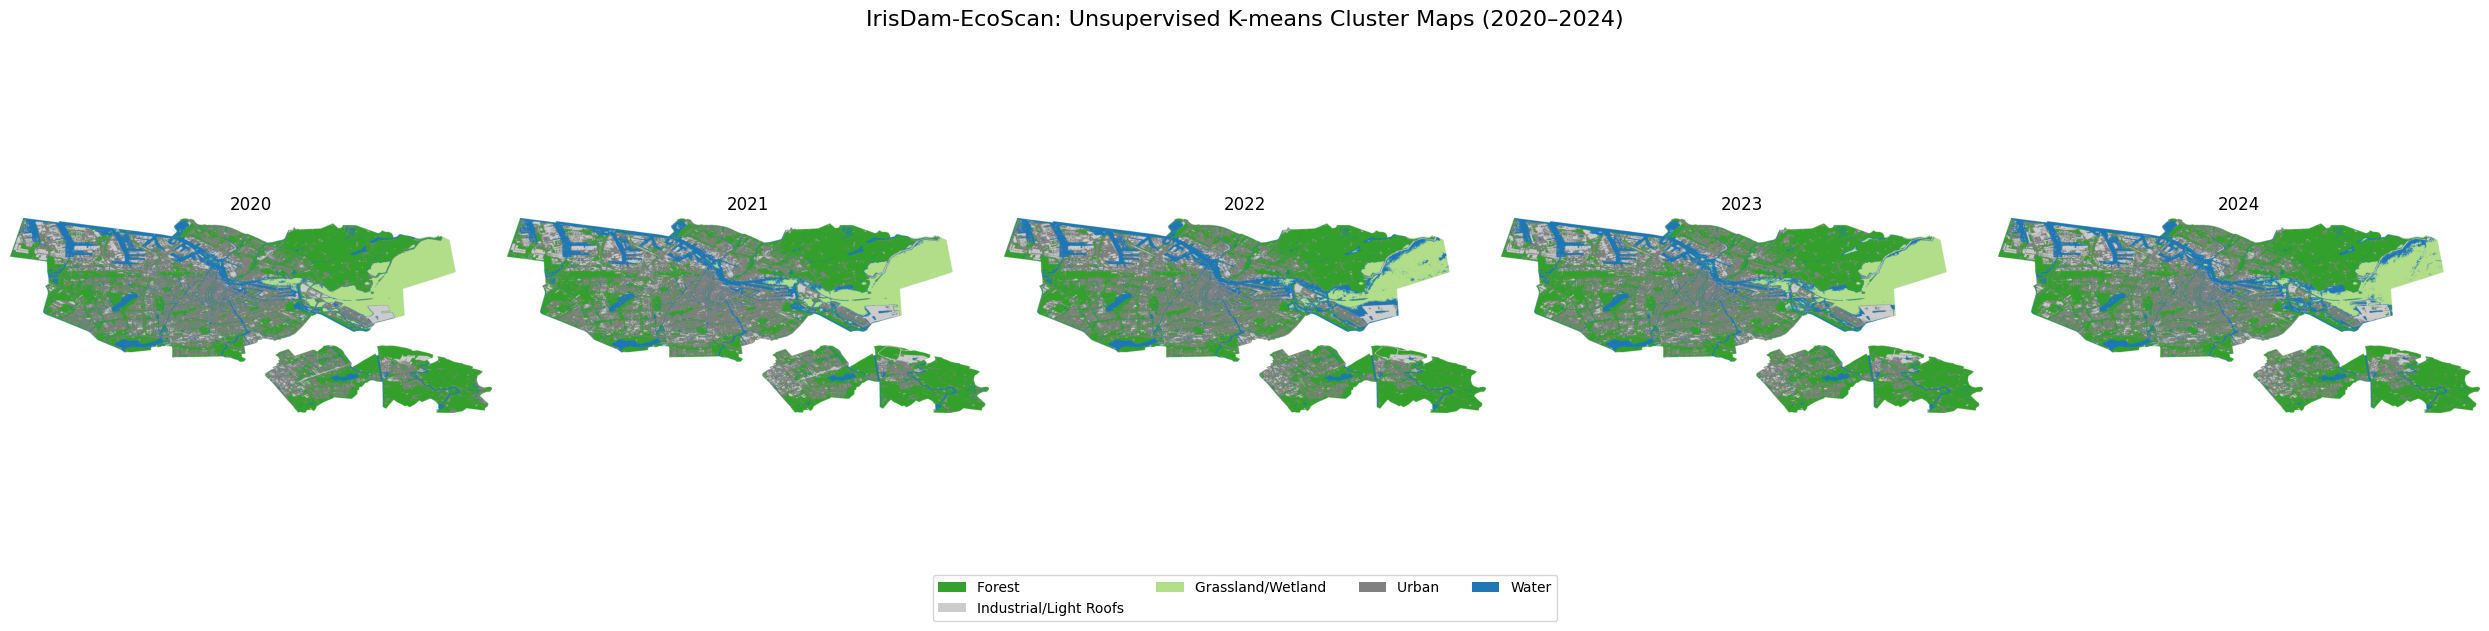

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np
from matplotlib.patches import Patch


kmeans_labels = {
    0: "Forest ",
    1: "Industrial/Light Roofs ",
    2: "Grassland/Wetland ",
    3: "Urban ",
    4: "Water"
}

years = range(2020, 2025)
fig, axes = plt.subplots(1, 5, figsize=(25, 6))
axes = axes.flatten()

for i, yr in enumerate(years):
    with rasterio.open(MAPS / f'kmeans_ams_{yr}.tif') as src:
        label_img = src.read(1)

    rgb = np.ones(label_img.shape + (3,), dtype='float32')
    for k, col in palette.items():
        rgb[label_img == k] = col

    axes[i].imshow(rgb)
    axes[i].axis('off')
    axes[i].set_title(str(yr))

# Add legend
legend_elements = [Patch(facecolor=palette[i], label=kmeans_labels[i]) for i in palette]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))

plt.suptitle("IrisDam-EcoScan: Unsupervised K-means Cluster Maps (2020–2024)", fontsize=16)
plt.tight_layout()
plt.savefig(FIG / "kmeans_cluster_maps_panel.png", dpi=300, bbox_inches='tight')
plt.show()

# 7. Cluster Distributions and Interpretation


## 7.1 Absolute Cluster Frequencies

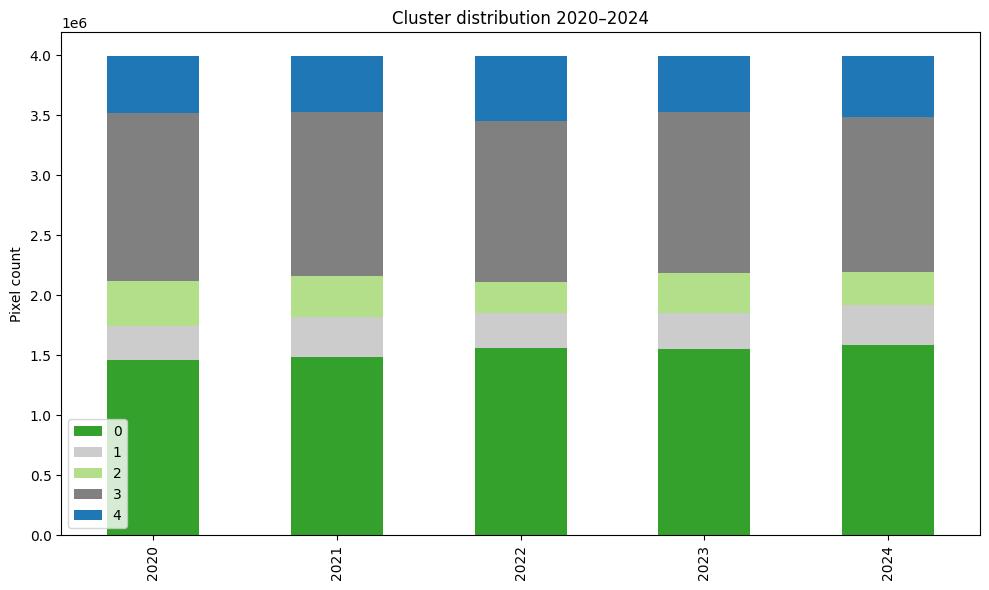

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute cluster frequencies
freq = {}
for yr in range(2020, 2025):
    with rasterio.open(MAPS / f'kmeans_ams_{yr}.tif') as src:
        arr = src.read(1)
    vals, counts = np.unique(arr[arr != 255], return_counts=True)
    freq[yr] = {int(v): int(c) for v, c in zip(vals, counts)}

df = pd.DataFrame(freq).fillna(0).astype(int).T

# Define consistent cluster colours
palette = {
    0: (0.20, 0.63, 0.17),  # dark green (Forest)
    1: (0.80, 0.80, 0.80),  # light grey (Industrial)
    2: (0.70, 0.87, 0.54),  # light green (Grassland)
    3: (0.50, 0.50, 0.50),  # dark grey (Urban)
    4: (0.12, 0.47, 0.71),  # blue (Water)
}
cluster_colors = [palette[k] for k in sorted(palette.keys())]

# Plot bar chart
df.plot(kind='bar', stacked=True, figsize=(10, 6), color=cluster_colors)
plt.ylabel('Pixel count')
plt.title('Cluster distribution 2020–2024')
plt.tight_layout()
plt.savefig(FIG / 'cluster_distribution.png', dpi=250)
plt.show()

## 7.2 Proportional Cluster Frequencies
Compare relative prevalence of classes (removes bias from changing pixel counts).

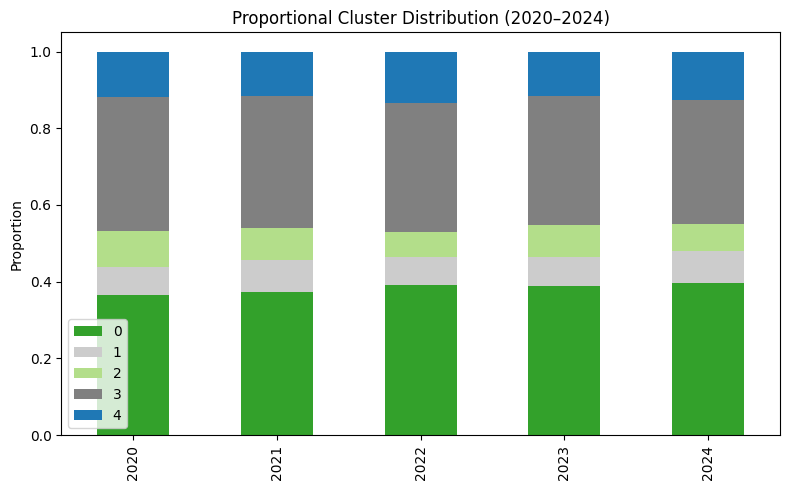

In [ ]:
# Proportional cluster distribution
df_norm = df.div(df.sum(axis=1), axis=0)

df_norm.plot(kind='bar', stacked=True, figsize=(8, 5), color=cluster_colors)
plt.ylabel('Proportion')
plt.title('Proportional Cluster Distribution (2020–2024)')
plt.tight_layout()
plt.savefig(FIG / 'cluster_distribution_proportional.png', dpi=250)
plt.show()

## 7.3 Cluster Centroid Summary and Interpretation
Display the feature averages for each cluster and assign likely land cover types based on their spectral and index profiles.

In [ ]:
import pandas as pd

# Round centroids for clarity and create DataFrame
df_centroids = pd.DataFrame(centroids, columns=[
    'blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'NDVI', 'NDWI', 'NDBI'
]).round(3)

# Add manual interpretation (based on visual and spectral inspection)
df_centroids['Likely Class'] = [
    'Forest (High NDVI, Low NDWI)',         # Cluster 0
    'Industrial (High Red/Reflectance)',    # Cluster 1
    'Wetland/Grassland (High NDWI/NDVI)',   # Cluster 2
    'Urban (Moderate Reflectance)',         # Cluster 3
    'Water (Low Reflectance, Water-like)'   # Cluster 4
]

# Display styled table
df_centroids.style.set_caption("K-Means Cluster Centroids and Interpretations")

,blue,green,red,nir,swir1,swir2,NDVI,NDWI,NDBI,Likely Class
0,0.115000,0.238000,0.122000,0.660000,0.597000,0.393000,0.673000,-0.455000,-0.033000,"Forest (High NDVI, Low NDWI)"
1,0.783000,0.798000,0.796000,0.474000,0.789000,0.804000,-0.259000,0.260000,0.253000,Industrial (High Red/Reflectance)
2,0.192000,0.274000,0.152000,0.024000,0.004000,0.003000,-0.725000,0.837000,-0.807000,Wetland/Grassland (High NDWI/NDVI)
3,0.317000,0.359000,0.346000,0.327000,0.562000,0.542000,-0.036000,0.059000,0.277000,Urban (Moderate Reflectance)
4,0.050000,0.083000,0.049000,0.044000,0.117000,0.106000,-0.040000,0.343000,0.576000,"Water (Low Reflectance, Water-like)"


# Enviromental Impact summary

In [ ]:
# End timer
end_time = time.time()
duration_sec = end_time - start_time
duration_hr = duration_sec / 3600

# Assumptions
CPU_POWER_W = 20
CARBON_INTENSITY = 0.325  # kg CO₂/kWh (Netherlands grid average)
ELECTRICITY_COST = 0.35   # €/kWh (Netherlands average)

# Energy used (kWh) = power (kW) × time (h)
energy_kwh = (CPU_POWER_W / 1000) * duration_hr
co2_kg = energy_kwh * CARBON_INTENSITY
cost_gbp = energy_kwh * ELECTRICITY_COST

# Print results
print(f"Runtime: {duration_hr:.4f} hours")
print(f"Energy used: {energy_kwh:.6f} kWh")
print(f"CO₂ emitted: {co2_kg:.6f} kg CO₂eq")
print(f"Estimated cost: €{cost_gbp:.4f}")

Runtime: 0.1418 hours
Energy used: 0.002836 kWh
CO₂ emitted: 0.000922 kg CO₂eq
Estimated cost: €0.0010
